In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/MyDrive/Datasets/Mall_Customers.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df=pd.read_csv(path)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
X=df.iloc[:,3:].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

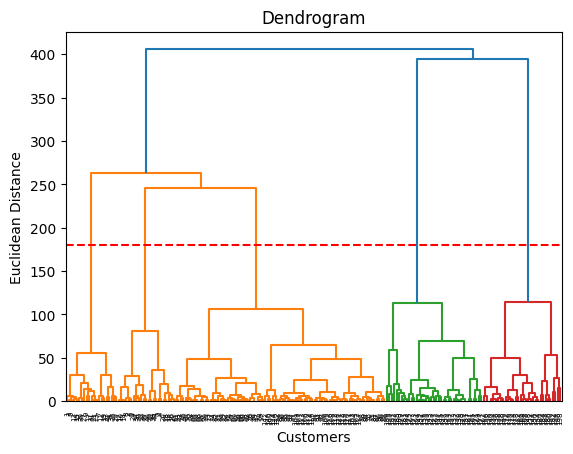

In [ ]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(X,method='ward'))
plt.axhline(y=180,color='r',linestyle='--')
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
y_hc=hc.fit_predict(X)
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

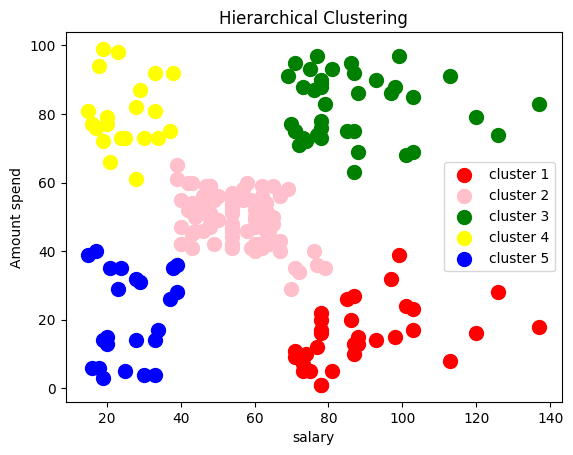

In [ ]:
plt.scatter(X[y_hc==0,0],X[y_hc==0,1],s=100,c='red',label='cluster 1')
plt.scatter(X[y_hc==1,0],X[y_hc==1,1],s=100,c='pink',label='cluster 2')
plt.scatter(X[y_hc==2,0],X[y_hc==2,1],s=100,c='green',label='cluster 3')
plt.scatter(X[y_hc==3,0],X[y_hc==3,1],s=100,c='yellow',label='cluster 4')
plt.scatter(X[y_hc==4,0],X[y_hc==4,1],s=100,c='blue',label='cluster 5')
plt.xlabel("salary")
plt.ylabel("Amount spend")
plt.title("Hierarchical Clustering")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score=silhouette_score(X,y_hc)
print("Silhouette Score for Hierarchical Clustering",score)

Silhouette Score for Hierarchical Clustering 0.5529945955148897


Dataset Preview
  sentiment                                               text
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...
TFIDF Shape: (4846, 2000)


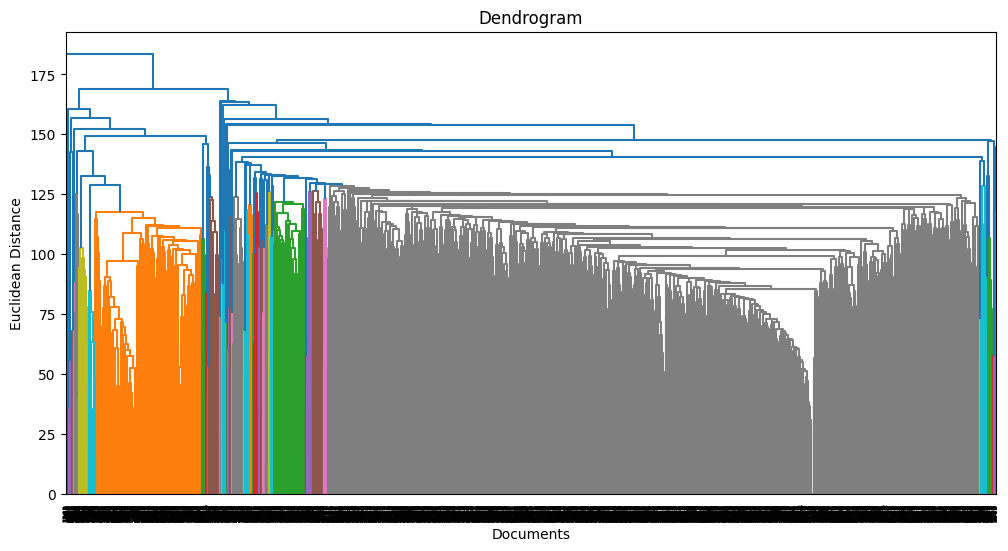


Silhouette Score: -0.04309054371701052


---- Cluster 0 ----
0    According to Gran , the company has no plans t...
1    Technopolis plans to develop in stages an area...
2    The international electronic industry company ...
Name: text, dtype: object

---- Cluster 1 ----
1056    Medical Devices - Russia This brand-new market...
1577    Pharmaceuticals - Belgium This brand-new marke...
1578    Pharmaceuticals - Czech Republic This brand-ne...
Name: text, dtype: object

---- Cluster 2 ----
5    FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
6    For the last quarter of 2010 , Componenta 's n...
7    In the third quarter of 2010 , net sales incre...
Name: text, dtype: object

---- Cluster 3 ----
1276    Last July , the group said it intended to relo...
1324    Rapala aims to move the distribution unit Rago...
1384    The group intends to relocate warehouse and of...
Name: text, dtype: object

Sentiment vs Cluster Table

cluster       0   1    2  3
sentiment                  
negative

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch


from sklearn.metrics import silhouette_score


path = '/content/drive/MyDrive/Datasets/all-data.csv'

# Dataset has no header
df = pd.read_csv(path, encoding='latin1', header=None)

# Give column names
df.columns = ['sentiment', 'text']

print("Dataset Preview")
print(df.head())


tfidf = TfidfVectorizer(
    stop_words='english',   # remove common words
    max_features=2000       # top important words
)

# Transform text to numeric matrix
X = tfidf.fit_transform(df['text']).toarray()

print("TFIDF Shape:", X.shape)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



plt.figure(figsize=(12,6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Euclidean Distance")
plt.show()

# ---- After seeing dendrogram choose k ----
k = 4  # you can change after seeing graph


hc = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

labels = hc.fit_predict(X_scaled)

df['cluster'] = labels


score = silhouette_score(X_scaled, labels)

print("\n============================")
print("Silhouette Score:", score)
print("============================\n")



for i in range(k):
    print(f"\n---- Cluster {i} ----")
    print(df[df['cluster']==i]['text'].head(3))

print("\nSentiment vs Cluster Table\n")
print(pd.crosstab(df['sentiment'], df['cluster']))


df.to_csv("hierarchical_result.csv", index=False)

print("\nSaved output to hierarchical_result.csv")
